# EDA Data Overview

**Data Mode Configuration**:
- Set `USE_SAMPLE = False` in the first cell for full dataset analysis (production)
- Set `USE_SAMPLE = True` in the first cell for quick sample testing (development)

## Distribution Analysis

**Note**: Quality assessment of processed data moved to `01_Data_Understanding/04b_processed_data_quality.ipynb`

This section focuses on exploring distributions and patterns in order/product data.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import importlib
import sys
from pathlib import Path

from IPython.display import display


In [2]:
DATA_PATH = '../../data/processed/quality'

orders = pd.read_csv(Path(DATA_PATH) / 'orders_clean.csv')
order_products_prior = pd.read_csv(Path(DATA_PATH) / 'order_products_prior_clean.csv')
order_products_train = pd.read_csv(Path(DATA_PATH) / 'order_products_train_clean.csv')
products = pd.read_csv(Path(DATA_PATH) / 'products_clean.csv')
aisles = pd.read_csv(Path(DATA_PATH) / 'aisles_clean.csv')
departments = pd.read_csv(Path(DATA_PATH) / 'departments_clean.csv')

tables = {
    'orders': orders,
    'order_products_prior': order_products_prior,
    'order_products_train': order_products_train,
    'products': products,
    'aisles': aisles,
    'departments': departments,
}

### Intermediate Cache (Fast Reload)

This notebook stores a cached intermediate DataFrame at:
- `data/interim/notebook_cache/eda_overview_merged_full.pkl` (when `USE_SAMPLE=False`)
- `data/interim/notebook_cache/eda_overview_merged_sample.pkl` (when `USE_SAMPLE=True`)

On first run, it creates the cache. On later runs, it loads directly from cache to save time.

To rebuild cache without manually deleting files, set `FORCE_REFRESH_CACHE = True` in Cell 4, run once, then set it back to `False`.

In [3]:
tables['orders'][['user_id', 'order_number', 'order_hour_of_day', 'days_since_prior_order']].head(10)

,user_id,order_number,order_hour_of_day,days_since_prior_order
0,1,1,8,0.0
1,1,2,7,15.0
2,1,3,12,21.0
3,1,4,7,29.0
4,1,5,15,28.0
5,1,6,7,19.0
6,1,7,9,20.0
7,1,8,14,14.0
8,1,9,16,0.0
9,1,10,8,30.0


In [4]:
palette_level = {
    'Strong': '#c8553d',
    'Moderate': '#4c956c',
    'Weak': '#577590',
    'None': '#b7b7a4'
}
churn_palette = {0: '#4c78a8', 1: '#e45756'}
level_order = ['Strong', 'Moderate', 'Weak', 'None']

sns.set_theme(style="whitegrid")

In [5]:
tables['order_products_prior']["reordered"].unique()

array([1, 0])

In [6]:
profile_rows = []

for table_name, df in tables.items():
    for col in df.columns:
        series = df[col]
        non_null = series.dropna()
        
        profile_rows.append({
            "table": table_name,
            "column": col,
            "non_null": len(non_null),
            "unique": non_null.nunique(),
            "missing_pct": f"{(series.isna().mean() * 100):.2f}%",
            "dtype": str(df[col].dtype)
        })

# แสดงตารางสรุปทีเดียว
profile_summary = pd.DataFrame(profile_rows)
display(profile_summary)

,table,column,non_null,unique,missing_pct,dtype
0,orders,order_id,3421083,3421083,0.00%,int64
1,orders,user_id,3421083,206209,0.00%,int64
2,orders,eval_set,3421083,3,0.00%,str
3,orders,order_number,3421083,100,0.00%,int64
4,orders,order_dow,3421083,7,0.00%,int64
5,orders,order_hour_of_day,3421083,24,0.00%,int64
6,orders,days_since_prior_order,3421083,31,0.00%,float64
7,order_products_prior,order_id,32434489,3214874,0.00%,int64
8,order_products_prior,product_id,32434489,49677,0.00%,int64
9,order_products_prior,add_to_cart_order,32434489,145,0.00%,int64


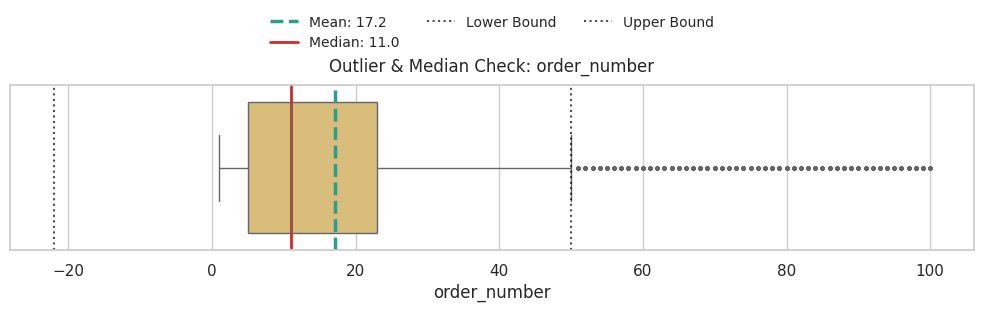

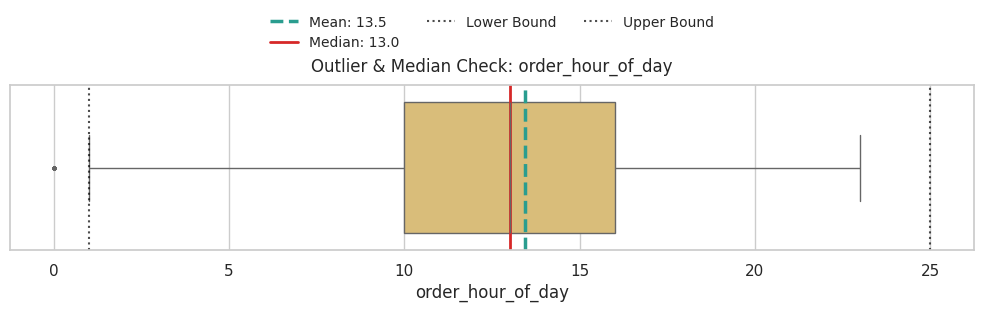

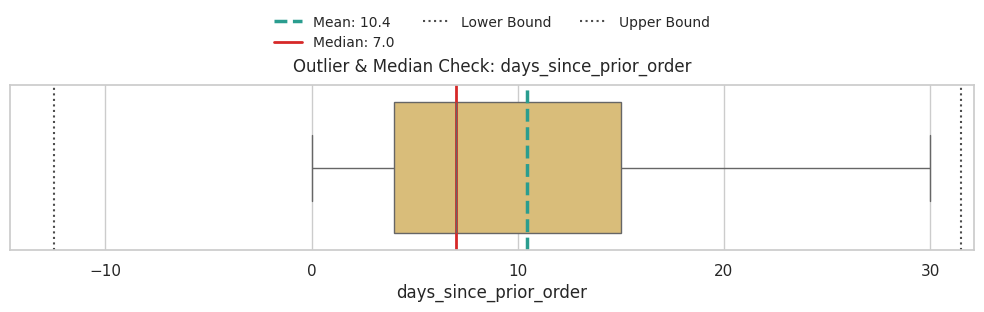

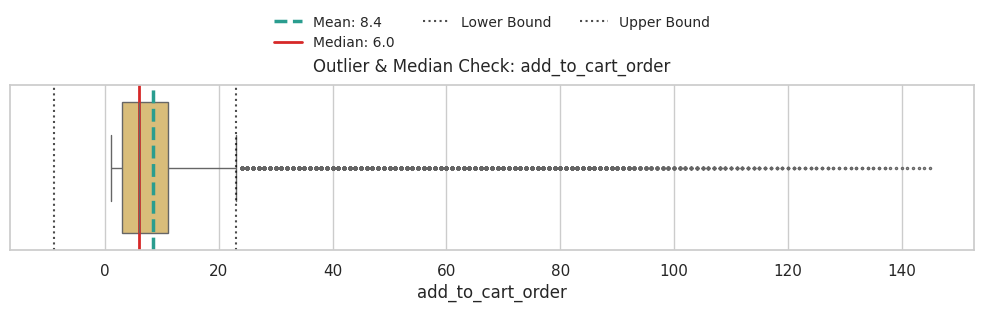

In [7]:
# 1. กำหนดตารางเป้าหมาย
targets = {
    'order_number': tables['orders'],
    'order_hour_of_day': tables['orders'],
    'days_since_prior_order': tables['orders'],
    'add_to_cart_order': tables['order_products_prior']
}

for col, df_source in targets.items():
    s = df_source[col].dropna()
    
    # คำนวณค่าสถิติ
    mean_val = s.mean()
    median_val = s.median()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    
    # สร้างกราฟ
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # วาด Boxplot (โชว์จุด Outlier เล็กๆ ด้วย fliersize)
    sns.boxplot(x=s, color="#e9c46a", ax=ax, fliersize=1.5)

    # วาดเส้นค่าสถิติต่างๆ
    ax.axvline(mean_val, color="#2a9d8f", linestyle="--", linewidth=2.5, label=f"Mean: {mean_val:.1f}")
    ax.axvline(median_val, color="#d62828", linestyle="-", linewidth=2, label=f"Median: {median_val:.1f}")
    ax.axvline(lower, color="#000000", linestyle=":", alpha=0.7, label="Lower Bound")
    ax.axvline(upper, color="#000000", linestyle=":", alpha=0.7, label="Upper Bound")

    # --- การย้าย Legend ไปไว้ด้านบน ---
    ax.legend(
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.50), # (x, y) โดย 1.50 คืออยู่เหนือกราฟขึ้นไป
        ncol=3,                     # แบ่งเป็น 3 คอลัมน์เพื่อให้วางเรียงแนวนอน
        fontsize='small',
        frameon=False               # เอาตารางสี่เหลี่ยมออกให้ดู Clean
    )

    # ปรับแต่งความสวยงาม
    ax.set_title(f"Outlier & Median Check: {col}", fontsize=12, pad=10)
    
    plt.tight_layout()
    plt.show()

## Fix Outlier To Find Central tendency 

In [8]:
merged_df = tables['order_products_prior'].merge(
    tables['orders'][['order_id', 'user_id', 'order_number']], 
    on='order_id', 
    how='left'
)

cumulative_reorder = merged_df.groupby('user_id')['reordered'].cumsum()
merged_df['cumulative_reorder_per_customer'] = cumulative_reorder

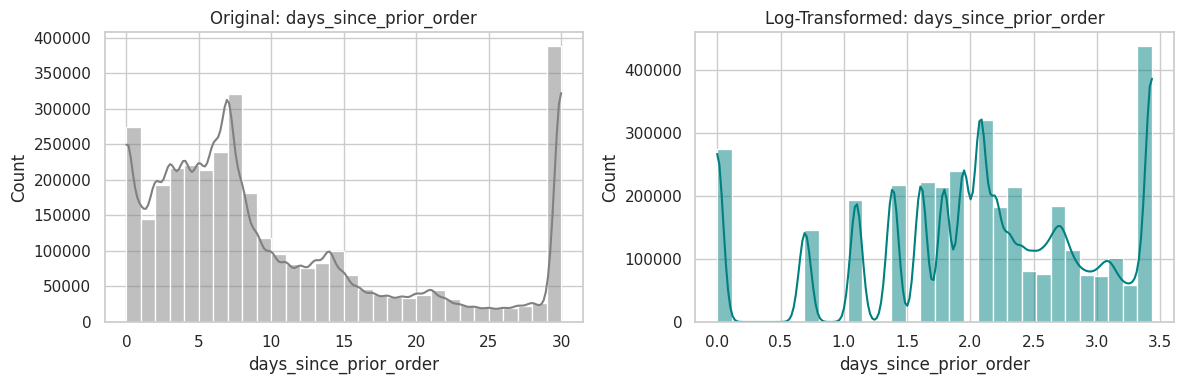

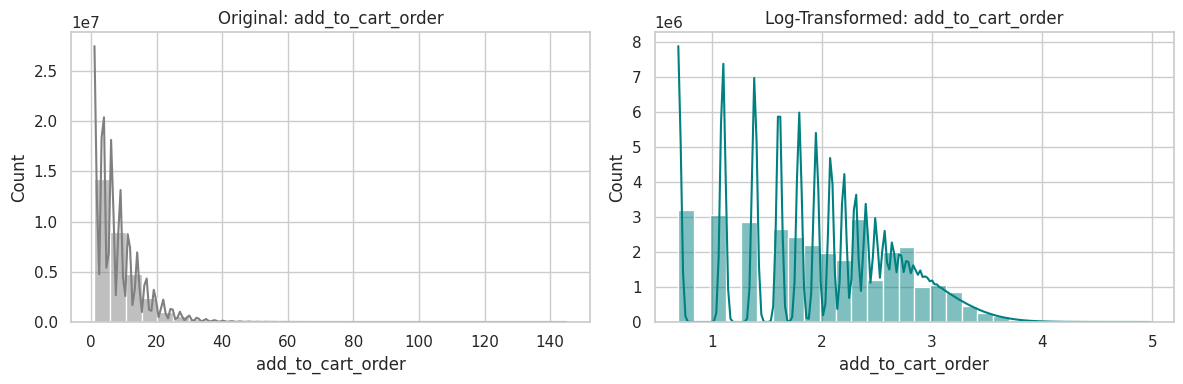

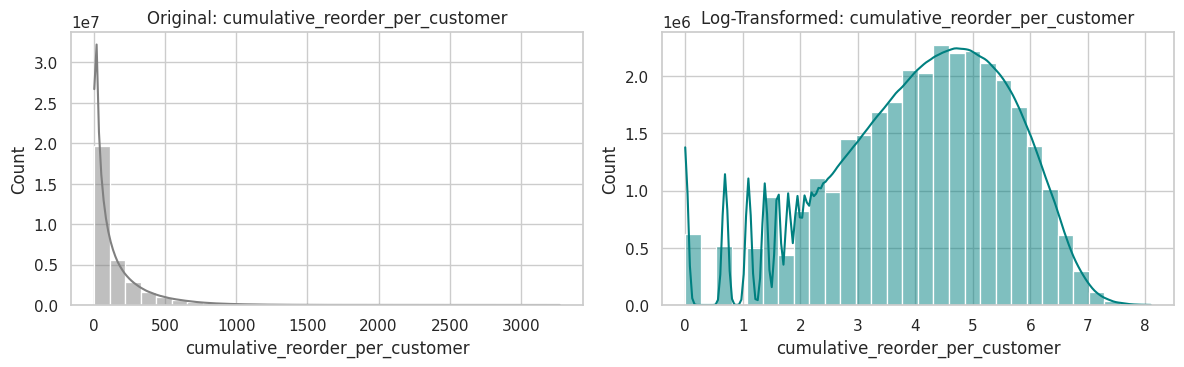

In [9]:
import numpy as np

# 1. ระบุแหล่งที่มาให้ถูกต้อง
# สมมติว่าคุณเก็บ 'cumulative_reorder_per_customer' ไว้ใน merged_df แล้ว
log_targets = {
    'days_since_prior_order': tables['orders'],
    'add_to_cart_order': tables['order_products_prior'],
    'cumulative_reorder_per_customer': merged_df # ใช้ตารางที่คุณคำนวณไว้
}

for col, df_source in log_targets.items():
    # ดึงข้อมูลและทำ Log1p
    original_data = df_source[col].dropna()
    log_data = np.log1p(original_data)

    # สร้างกราฟเปรียบเทียบ (ก่อนทำ vs หลังทำ)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # ฝั่งซ้าย: ข้อมูลเดิม
    sns.histplot(original_data, kde=True, ax=axes[0], color='gray', bins=30)
    axes[0].set_title(f"Original: {col}")
    
    # ฝั่งขวา: หลังทำ Log
    sns.histplot(log_data, kde=True, ax=axes[1], color='teal', bins=30)
    axes[1].set_title(f"Log-Transformed: {col}")
    
    plt.tight_layout()
    plt.show()

การใช้ Log Transformation ช่วยลด Skewness และบรรเทาอิทธิพลของ Outlier ในคอลัมน์ days_since_prior_order, add_to_cart_order และ order_hour_of_day ได้อย่างมีนัยสำคัญ ส่งผลให้ค่า Mean ขยับเข้าใกล้ Median (Central Tendency) มากขึ้น ซึ่งช่วยเพิ่มประสิทธิภาพและความเที่ยงตรง (Stability) ในการ Train Model

อย่างไรก็ตาม สำหรับ cumulative_reorder_per_customer แม้การทำ Log จะช่วยให้รูปทรงข้อมูลดีขึ้น แต่ยังมี Extreme Outliers (กลุ่ม Super VIP) ที่มีอิทธิพลสูงเกินกว่าที่ Log จะจัดการได้หมด จึงควรพิจารณาเทคนิคอื่นเพิ่มเติม เช่น การทำ Segmentation หรือ Clipping ควบคู่ไปด้วย

### สรุป Insight
- ลูกค้า ส่วนใหญ่เพิามสินค้า ใน ordercart ไม่มาก มีค่าเฉลี่ย 5 ชิ้นต่อตะกร้าสินค้า

- 

## Display Outlier Group of Data

In [10]:
# 1. กำหนดคู่ของ "ชื่อคอลัมน์" และ "ตารางที่มันอยู่"
# หมายเหตุ: cumulative_reorder_per_customer ต้องสร้างไว้ใน merged_df ก่อนนะครับ
target_cols = {
    'days_since_prior_order': tables['orders'],
    'add_to_cart_order': tables['order_products_prior'],
    'cumulative_reorder_per_customer': merged_df 
}

# 2. ฟังก์ชันเช็ค Outlier (สูตร IQR)
def check_outliers(data):
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return data[(data < lower) | (data > upper)]

# 3. วนลูปเช็คทีละคอลัมน์
for col, df_source in target_cols.items():
    if col not in df_source.columns:
        print(f"⚠️ Skip: {col} not found in the table")
        continue
        
    original_series = df_source[col].dropna()
    log_series = np.log1p(original_series)

    # คำนวณ Outlier
    outliers_before = check_outliers(original_series)
    outliers_after = check_outliers(log_series)

    # 4. แสดงผลเปรียบเทียบ
    print(f"📊 Column: {col}")
    print(f"--- BEFORE LOG ---")
    print(f"Outliers: {len(outliers_before):,} / {len(original_series):,} ({(len(outliers_before)/len(original_series)):.2%})")

    print(f"--- AFTER LOG (np.log1p) ---")
    print(f"Outliers: {len(outliers_after):,} / {len(log_series):,} ({(len(outliers_after)/len(log_series)):.2%})")
    print("-" * 40)

📊 Column: days_since_prior_order
--- BEFORE LOG ---
Outliers: 0 / 3,421,083 (0.00%)
--- AFTER LOG (np.log1p) ---
Outliers: 0 / 3,421,083 (0.00%)
----------------------------------------
📊 Column: add_to_cart_order
--- BEFORE LOG ---
Outliers: 1,357,124 / 32,434,489 (4.18%)
--- AFTER LOG (np.log1p) ---
Outliers: 7,478 / 32,434,489 (0.02%)
----------------------------------------
📊 Column: cumulative_reorder_per_customer
--- BEFORE LOG ---
Outliers: 2,461,219 / 32,434,489 (7.59%)
--- AFTER LOG (np.log1p) ---
Outliers: 0 / 32,434,489 (0.00%)
----------------------------------------


In [13]:
for col in df.select_dtypes(include="number").columns:
    outliers = check_outliers(df[col])

    if len(outliers) > 0:
        sns.histplot(outliers, bins=30)  # ลด bins
        plt.xlim(outliers.min(), outliers.max())  # zoom
        plt.title(f"{col} (Only Outliers)")
        plt.show()

In [15]:
summary_rows = []

for col in df.select_dtypes(include="number").columns:
    outliers = check_outliers(df[col])

    if len(outliers) > 0:
        stats = outliers.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_dict()
        stats["column"] = col
        summary_rows.append(stats)

if summary_rows:
    outlier_summary = pd.DataFrame(summary_rows).set_index("column")

    with pd.option_context(
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None,
    ):
        display(outlier_summary)
else:
    print("No numeric outliers found by IQR rule.")

No numeric outliers found by IQR rule.


### Outlier Analysis & Customer Behavior Insight

จากการวิเคราะห์ข้อมูล พบว่า outlier ที่เกิดขึ้นในตัวแปรสำคัญ เช่น `add_to_cart_order` และ `cumulative_reorder_per_customer` ไม่ได้เป็นเพียง noise ของข้อมูล แต่สะท้อนถึงพฤติกรรมของลูกค้าที่แตกต่างกันอย่างมีนัยสำคัญ

สามารถตั้งสมมติฐานได้ว่าลูกค้าถูกแบ่งออกเป็น 2 กลุ่มหลัก ได้แก่:

1. **Bulk Buyers**
   กลุ่มลูกค้าที่มีการสั่งซื้อสินค้าในปริมาณมากภายในคำสั่งซื้อเดียว (high basket size) ซึ่งส่งผลให้ค่า `add_to_cart_order` มีค่าสูงผิดปกติ

2. **Loyal Customers**
   กลุ่มลูกค้าที่มีความถี่ในการสั่งซื้อสูง หรือมีการซื้อซ้ำอย่างต่อเนื่อง สะท้อนผ่านค่า `order_number` และ `cumulative_reorder_per_customer` ที่อยู่ในระดับสูง

เพื่อยืนยันสมมติฐานดังกล่าว ได้มีการสร้างตัวแปรเพิ่มเติม เช่น basket size และทำการแบ่งกลุ่มลูกค้าตาม quantile (เช่น top 5%) เพื่อวิเคราะห์ความสัมพันธ์ระหว่างกลุ่มลูกค้าแต่ละประเภท

ผลการวิเคราะห์ช่วยให้เข้าใจว่า outlier ใน dataset นี้ไม่ได้เป็นข้อผิดพลาดของข้อมูล แต่เป็นตัวแทนของ customer segments ที่มีพฤติกรรมเฉพาะ ซึ่งสามารถนำไปต่อยอดในการทำ customer segmentation และการวิเคราะห์เชิงธุรกิจได้

---

**Conclusion:**
Outliers in this dataset provide valuable insights into distinct customer behaviors, particularly identifying high-volume purchasers and long-term loyal customers, rather than indicating data anomalies.


# 📊 Dataset Insight Summary

## 🧠 Overview
- Dataset นี้มี **32.4 ล้านแถว** (ขนาดใหญ่มาก)
- เป็นข้อมูลเกี่ยวกับ **พฤติกรรมการสั่งซื้อสินค้า (order-level + product-level)**
- แต่ละแถวแทน **1 product ใน 1 order** (ไม่ใช่ 1 order ตรง ๆ)

---

## 🧾 1. Order / Transaction Behavior

### 🔹 add_to_cart_order
- โดยเฉลี่ยลูกค้าซื้อประมาณ **6–8 ชิ้นต่อ order**
- มีบาง order ที่ซื้อจำนวนมากผิดปกติ (สูงสุด 145 ชิ้น)  
➡️ บ่งบอกถึง **outliers / bulk buyers**

### 🔹 order_number
- ลูกค้าส่วนใหญ่มีประวัติการสั่งซื้อหลายครั้ง (**median = 11**)  
➡️ แสดงว่ามี **repeat customers จำนวนมาก**

---

## 🔁 2. Customer Loyalty / Behavior

### 🔹 reordered
- ประมาณ **59% ของสินค้าเป็นการซื้อซ้ำ**  
➡️ บ่งบอกว่า user มี **brand/product loyalty สูง**

### 🔹 cumulative_reorder_per_customer
- ลูกค้าบางกลุ่มมีการซื้อซ้ำจำนวนมากผิดปกติ  
➡️ มี **heavy users / highly loyal customers**

---

## ⏰ 3. Time Behavior

### 🔹 order_hour_of_day
- ลูกค้าส่วนใหญ่สั่งซื้อช่วง **สาย–บ่าย (10:00–16:00)**

### 🔹 order_dow (Day of Week)
- ค่าเฉลี่ย ≈ 2.7 (ถ้า 0 = Sunday)  
➡️ การสั่งซื้อกระจายทั้งสัปดาห์ แต่มีแนวโน้มไปช่วง **ต้น–กลางสัปดาห์**

### 🔹 days_since_prior_order
- ลูกค้ากลับมาซื้อซ้ำทุก **~1 สัปดาห์**  
➡️ เป็นพฤติกรรมแบบ **routine purchase**

---

## 🧍 4. User Distribution

### 🔹 user_id
- Dataset นี้มี user ประมาณ **200K คน**

---

## 🧪 5. Data Quality Insight

### 🔹 eval_set
- มีค่าเดียว = `"prior"`  
➡️ Dataset นี้เป็น **historical data**
➡️ เหมาะสำหรับ **EDA / Training**
➡️ ยังไม่มี **train/test split** ใน table นี้

---

## 🔥 Key Insights

- ลูกค้ามีพฤติกรรม **ซื้อซ้ำสูง (~59%)**
- มี **loyal customer segment** ชัดเจน
- การซื้อมี pattern:
  - ช่วงเวลา: **กลางวัน**
  - ความถี่: **ทุก ~7 วัน**
- พบ **bulk buyers / outliers**
- Dataset นี้เหมาะสำหรับ:
  - 📌 Recommender System
  - 📌 Customer Segmentation
  - 📌 Repeat Purchase Prediction

## Next Step

Detailed customer-level bivariate analysis was moved to:
`notebooks/02_Exploratory_Data_Analysis/02_customer_behavior.ipynb`

This overview notebook now focuses on quick distribution scanning only.